<a href="https://colab.research.google.com/github/Raka7317/DATA-STRUCTURE-/blob/main/text%26speechlast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ═══════════════════════════════════════════
# Cell 1
# ═══════════════════════════════════════════
# ── Install all required packages ──────────────────────────────
!pip install -q torch torchaudio transformers datasets accelerate
!pip install -q librosa soundfile audiomentations
!pip install -q openai-whisper
!pip install -q scikit-learn matplotlib seaborn pandas

import os, sys, time, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from collections import defaultdict

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
print('\nAll packages loaded. Ready!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 26.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 48.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB

All packages loaded. Ready!


In [2]:
# ═══════════════════════════════════════════
# Cell 2
# ═══════════════════════════════════════════
import urllib.request, zipfile

url = 'https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip'
if not os.path.exists('RAVDESS'):
    print('Downloading RAVDESS (~215 MB)...')
    urllib.request.urlretrieve(url, 'ravdess.zip')
    with zipfile.ZipFile('ravdess.zip', 'r') as z:
        z.extractall('RAVDESS')
    os.remove('ravdess.zip')
    print('Download complete!')
else:
    print('RAVDESS already present.')

EMOTION_MAP = {
    '01': 'neutral', '02': 'calm',    '03': 'happy',    '04': 'sad',
    '05': 'angry',   '06': 'fearful', '07': 'disgust',  '08': 'surprised'
}
EMOTIONS = sorted(EMOTION_MAP.values())
N_CLASSES = len(EMOTIONS)

records = []
for f in Path('RAVDESS').rglob('*.wav'):
    parts = f.stem.split('-')
    records.append({
        'path': str(f),
        'emotion': EMOTION_MAP[parts[2]],
        'actor': int(parts[6]),
        'intensity': int(parts[3]),
    })
df = pd.DataFrame(records)

# Actor-disjoint split (actors 20-24 = test, consistent with your original)
test_actors = {20, 21, 22, 23, 24}
df_train = df[~df['actor'].isin(test_actors)].reset_index(drop=True)
df_test  = df[ df['actor'].isin(test_actors)].reset_index(drop=True)

le = LabelEncoder()
le.fit(EMOTIONS)
df_train['label'] = le.transform(df_train['emotion'])
df_test['label']  = le.transform(df_test['emotion'])

print(f'Total samples : {len(df)}')
print(f'Train samples : {len(df_train)} (actors 1–19)')
print(f'Test  samples : {len(df_test)}  (actors 20–24)')
print(f'Emotion classes: {list(le.classes_)}')
print('\nClass distribution (train):')
print(df_train['emotion'].value_counts().to_string())

Download complete!
Total samples : 1440
Train samples : 1140 (actors 1–19)
Test  samples : 300  (actors 20–24)
Emotion classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]

Class distribution (train):
emotion
happy        152
surprised    152
disgust      152
calm         152
sad          152
angry        152
fearful      152
neutral       76


In [3]:
# ═══════════════════════════════════════════
# Cell 3
# ═══════════════════════════════════════════
# ── Audio config ───────────────────────────────────────────────
SR          = 16000   # all tiers resample to 16 kHz
DURATION    = 4.0     # seconds
N_SAMPLES   = int(SR * DURATION)
N_MELS      = 128
N_FFT       = 1024
HOP_LENGTH  = 160     # 10 ms hop
N_FRAMES    = int(DURATION * SR / HOP_LENGTH)  # ~400

# ── Load waveform helper ───────────────────────────────────────
def load_wav(path, target_sr=SR, duration=DURATION):
    """Load, resample, trim/pad to fixed length."""
    wav, sr = torchaudio.load(path)
    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, sr, target_sr)
    wav = wav.mean(0)  # mono
    target_len = int(target_sr * duration)
    if wav.shape[0] < target_len:
        wav = F.pad(wav, (0, target_len - wav.shape[0]))
    else:
        wav = wav[:target_len]
    return wav  # shape: (T,)

# ── SpecAugment (time + freq masking) ─────────────────────────
class SpecAugment(nn.Module):
    def __init__(self, freq_mask=30, time_mask=80, n_masks=2):
        super().__init__()
        self.freq_mask = freq_mask
        self.time_mask = time_mask
        self.n_masks   = n_masks

    def forward(self, spec):  # spec: (C, F, T)
        for _ in range(self.n_masks):
            f = random.randint(0, self.freq_mask)
            f0 = random.randint(0, spec.shape[-2] - f)
            spec[..., f0:f0+f, :] = 0
            t = random.randint(0, self.time_mask)
            t0 = random.randint(0, spec.shape[-1] - t)
            spec[..., t0:t0+t] = 0
        return spec

# ── MixUp ──────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.3):
    """MixUp augmentation for waveforms or spectrograms."""
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ── Label-smoothed cross-entropy ───────────────────────────────
class LabelSmoothingCE(nn.Module):
    def __init__(self, n_classes, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.n_classes = n_classes

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            smooth = torch.full_like(log_probs, self.smoothing / (self.n_classes - 1))
            smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        return -(smooth * log_probs).sum(dim=-1).mean()

# ── Training loop helper ───────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, scheduler=None,
                    use_mixup=True, grad_clip=1.0, scaler=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        x = batch['input'].to(device)
        y = batch['label'].to(device)
        optimizer.zero_grad()
        if use_mixup:
            x, y_a, y_b, lam = mixup_data(x, y)
        if scaler:
            with torch.cuda.amp.autocast():
                logits = model(x)
                loss = mixup_criterion(criterion, logits, y_a, y_b, lam) if use_mixup else criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(x)
            loss = mixup_criterion(criterion, logits, y_a, y_b, lam) if use_mixup else criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
        if scheduler:
            scheduler.step()
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=-1)
        if use_mixup:
            correct += (lam * (preds == y_a).float() + (1 - lam) * (preds == y_b).float()).sum().item()
        else:
            correct += (preds == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        x = batch['input'].to(device)
        y = batch['label'].to(device)
        with torch.cuda.amp.autocast():
            logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        all_preds.extend(logits.argmax(-1).cpu().tolist())
        all_labels.extend(y.cpu().tolist())
    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(all_labels), acc, all_preds, all_labels

# ── Plotting utilities ─────────────────────────────────────────
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['val_loss'],   label='Val')
    ax1.set_title(f'{title} — Loss'); ax1.legend()
    ax2.plot([a*100 for a in history['train_acc']], label='Train')
    ax2.plot([a*100 for a in history['val_acc']],   label='Val')
    ax2.set_title(f'{title} — Accuracy (%)'); ax2.legend()
    plt.tight_layout(); plt.show()

def plot_confusion(labels, preds, class_names, title, acc):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{title}\nAccuracy: {acc*100:.2f}%')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=35)
    plt.tight_layout(); plt.show()

# Global results tracker
ALL_RESULTS = {}
CLASS_NAMES = list(le.classes_)
print('Shared utilities loaded.')

Shared utilities loaded.


In [4]:
# ═══════════════════════════════════════════
# Cell 4
# ═══════════════════════════════════════════
# ── Tier 1 Dataset: Log-mel spectrogram ───────────────────────
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
    n_mels=N_MELS, f_min=50, f_max=8000
).to(device)

spec_augment = SpecAugment(freq_mask=30, time_mask=60, n_masks=2)

class MelDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df      = df
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav = load_wav(row['path'])  # (T,)

        # Random crop augmentation during training
        if self.augment:
            offset = random.randint(0, max(0, len(wav) - N_SAMPLES))
            wav = wav[offset:offset + N_SAMPLES]
            if len(wav) < N_SAMPLES:
                wav = F.pad(wav, (0, N_SAMPLES - len(wav)))

        # Compute mel on CPU, move to device in collate
        mel = torchaudio.functional.amplitude_to_DB(
            torchaudio.transforms.MelSpectrogram(
                sample_rate=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
                n_mels=N_MELS, f_min=50, f_max=8000
            )(wav),
            multiplier=10, amin=1e-10, db_multiplier=0.0, top_db=80.0
        )  # (128, T)

        # Normalize per sample
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)

        if self.augment:
            mel = spec_augment(mel.unsqueeze(0)).squeeze(0)

        return {'input': mel.unsqueeze(0), 'label': int(row['label'])}

t1_train_ds = MelDataset(df_train, augment=True)
t1_test_ds  = MelDataset(df_test,  augment=False)
t1_train_dl = DataLoader(t1_train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
t1_test_dl  = DataLoader(t1_test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
print(f'Tier 1 — Train batches: {len(t1_train_dl)} | Test batches: {len(t1_test_dl)}')

Tier 1 — Train batches: 36 | Test batches: 10


In [5]:
# ═══════════════════════════════════════════
# Cell 5
# ═══════════════════════════════════════════
# ── Tier 1 Model: CNN + Transformer Encoder ────────────────────

class ConvBlock(nn.Module):
    """Conv2D → BN → GELU → MaxPool with residual projection."""
    def __init__(self, in_ch, out_ch, pool=(2, 2)):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )
        self.pool = nn.MaxPool2d(pool)
        self.proj = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        residual = self.pool(self.proj(x))
        x = self.pool(self.conv(x))
        return x + residual


class AttentionPool(nn.Module):
    """Novel: learnable query vector for emotion-aware pooling."""
    def __init__(self, d_model):
        super().__init__()
        self.query = nn.Parameter(torch.randn(d_model))

    def forward(self, x):  # x: (B, T, D)
        scores = torch.einsum('btd,d->bt', x, self.query) / (x.shape[-1] ** 0.5)
        weights = F.softmax(scores, dim=-1)  # (B, T)
        return torch.einsum('bt,btd->bd', weights, x)  # (B, D)


class CNNTransformerSER(nn.Module):
    """
    Tier 1: CNN feature extractor + Transformer encoder + attention pooling.
    Input: (B, 1, 128, T) log-mel spectrogram
    """
    def __init__(self, n_classes=8, d_model=256, n_heads=8, n_layers=4, dropout=0.2):
        super().__init__()
        # CNN backbone: 1 → 64 → 128 → 256
        self.cnn = nn.Sequential(
            ConvBlock(1,   64,  pool=(2, 2)),   # (64, 64, T/2)
            nn.Dropout2d(0.1),
            ConvBlock(64,  128, pool=(2, 2)),   # (128, 32, T/4)
            nn.Dropout2d(0.1),
            ConvBlock(128, 256, pool=(2, 2)),   # (256, 16, T/8)
            nn.Dropout2d(0.1),
            ConvBlock(256, 256, pool=(4, 1)),   # (256, 4, T/8)
        )

        # Project to transformer dimension
        # The output of the CNN is (B, 256, 4, T'). After view and permute,
        # it becomes (B, T', 256 * 4) = (B, T', 1024).
        self.proj = nn.Linear(256 * 4, d_model)

        # Positional encoding (learnable)
        # The time dimension T' after CNN is N_FRAMES / (2*2*2) = 400 / 8 = 50
        self.pos_enc = nn.Parameter(torch.randn(1, 50, d_model) * 0.02)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model*4,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Emotion-aware attention pooling
        self.attn_pool = AttentionPool(d_model)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, n_classes)
        )

    def forward(self, x):  # x: (B, 1, 128, T)
        # CNN
        x = self.cnn(x)       # (B, 256, 4, T')
        B, C, H, T = x.shape
        x = x.view(B, C * H, T).permute(0, 2, 1)  # (B, T', C*H)

        # Project
        x = self.proj(x)       # (B, T', D)

        # Positional encoding
        x = x + self.pos_enc[:, :x.shape[1], :]

        # Transformer
        x = self.transformer(x)  # (B, T', D)

        # Attention pooling
        x = self.attn_pool(x)    # (B, D)

        # Classify
        return self.classifier(x)  # (B, n_classes)


t1_model = CNNTransformerSER(n_classes=N_CLASSES, d_model=256, n_heads=8, n_layers=4).to(device)
n_params = sum(p.numel() for p in t1_model.parameters() if p.requires_grad)
print(f'Tier 1 model parameters: {n_params/1e6:.2f}M')


Tier 1 model parameters: 5.84M


  TIER 1 TRAINING — CNN + Transformer
  Epoch  10/60 | Loss: 1.8710/1.9288 | Acc: 32.7%/29.0% | Best: 38.67% | ETA: 1644s
  Epoch  20/60 | Loss: 1.6908/1.6494 | Acc: 43.3%/40.0% | Best: 45.33% | ETA: 1264s
  Epoch  30/60 | Loss: 1.4886/1.4839 | Acc: 52.4%/51.7% | Best: 55.33% | ETA: 931s
  Epoch  40/60 | Loss: 1.4075/1.3956 | Acc: 60.9%/56.7% | Best: 58.33% | ETA: 615s
  Epoch  50/60 | Loss: 1.2536/1.3424 | Acc: 66.9%/58.3% | Best: 60.00% | ETA: 306s
  Epoch  60/60 | Loss: 1.2394/1.3478 | Acc: 69.3%/60.0% | Best: 60.00% | ETA: 0s

Tier 1 FINAL accuracy: 60.00%  (best val: 60.00%)


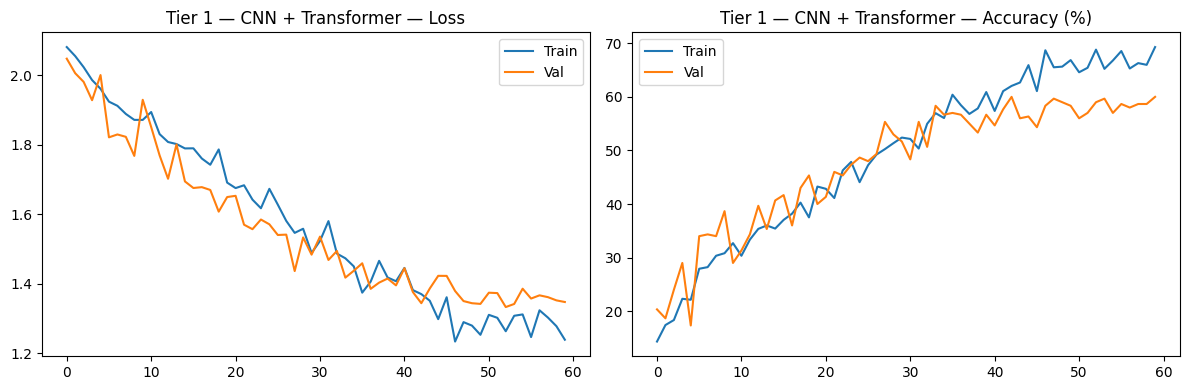

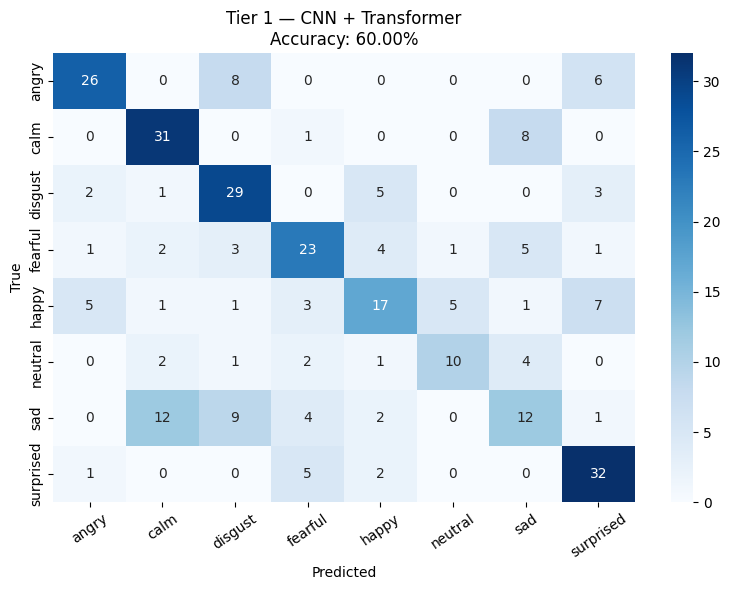

              precision    recall  f1-score   support

       angry       0.74      0.65      0.69        40
        calm       0.63      0.78      0.70        40
     disgust       0.57      0.72      0.64        40
     fearful       0.61      0.57      0.59        40
       happy       0.55      0.42      0.48        40
     neutral       0.62      0.50      0.56        20
         sad       0.40      0.30      0.34        40
   surprised       0.64      0.80      0.71        40

    accuracy                           0.60       300
   macro avg       0.60      0.59      0.59       300
weighted avg       0.59      0.60      0.59       300



In [6]:
# ═══════════════════════════════════════════
# Cell 6
# ═══════════════════════════════════════════
# ── Tier 1 Training ────────────────────────────────────────────
T1_EPOCHS   = 60
T1_LR       = 3e-4
T1_WARMUP   = 5

t1_criterion = LabelSmoothingCE(N_CLASSES, smoothing=0.1).to(device)
t1_optimizer = torch.optim.AdamW(t1_model.parameters(), lr=T1_LR, weight_decay=1e-4)

# Cosine schedule with linear warmup
total_steps   = T1_EPOCHS * len(t1_train_dl)
warmup_steps  = T1_WARMUP  * len(t1_train_dl)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.05, 0.5 * (1.0 + np.cos(np.pi * progress)))

t1_scheduler = torch.optim.lr_scheduler.LambdaLR(t1_optimizer, lr_lambda)
t1_scaler    = torch.cuda.amp.GradScaler()

t1_history   = defaultdict(list)
t1_best_acc  = 0.0
t1_best_state = None

print('='*60)
print('  TIER 1 TRAINING — CNN + Transformer')
print('='*60)
t0 = time.time()
for epoch in range(1, T1_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        t1_model, t1_train_dl, t1_optimizer, t1_criterion,
        scheduler=t1_scheduler, use_mixup=True, scaler=t1_scaler
    )
    val_loss, val_acc, _, _ = evaluate(t1_model, t1_test_dl, t1_criterion)
    t1_history['train_loss'].append(tr_loss)
    t1_history['train_acc'].append(tr_acc)
    t1_history['val_loss'].append(val_loss)
    t1_history['val_acc'].append(val_acc)
    if val_acc > t1_best_acc:
        t1_best_acc = val_acc
        t1_best_state = {k: v.cpu().clone() for k, v in t1_model.state_dict().items()}
    if epoch % 10 == 0:
        eta = (time.time() - t0) / epoch * (T1_EPOCHS - epoch)
        print(f'  Epoch {epoch:3d}/{T1_EPOCHS} | '
              f'Loss: {tr_loss:.4f}/{val_loss:.4f} | '
              f'Acc: {tr_acc*100:.1f}%/{val_acc*100:.1f}% | '
              f'Best: {t1_best_acc*100:.2f}% | ETA: {eta:.0f}s')

# Final eval with best weights
t1_model.load_state_dict(t1_best_state)
_, t1_final_acc, t1_preds, t1_labels = evaluate(t1_model, t1_test_dl, t1_criterion)
ALL_RESULTS['Tier 1 — CNN+Transformer'] = t1_final_acc
print(f'\nTier 1 FINAL accuracy: {t1_final_acc*100:.2f}%  (best val: {t1_best_acc*100:.2f}%)')
plot_history(t1_history, 'Tier 1 — CNN + Transformer')
plot_confusion(t1_labels, t1_preds, CLASS_NAMES, 'Tier 1 — CNN + Transformer', t1_final_acc)
print(classification_report(t1_labels, t1_preds, target_names=CLASS_NAMES))

In [7]:
# ═══════════════════════════════════════════
# Cell 7
# ═══════════════════════════════════════════
from transformers import HubertModel, AutoFeatureExtractor

# ── HuBERT feature extractor (handles normalization) ──────────
hubert_extractor = AutoFeatureExtractor.from_pretrained('facebook/hubert-base-ls960')

class HubertDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df      = df
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav = load_wav(row['path'], target_sr=16000)  # HuBERT requires 16 kHz

        # Waveform augmentation
        if self.augment:
            # Random gain
            gain = 10 ** (random.uniform(-6, 6) / 20)
            wav  = wav * gain
            # Random noise
            if random.random() < 0.3:
                wav = wav + torch.randn_like(wav) * 0.003

        # Normalize
        wav = wav / (wav.abs().max() + 1e-8)
        return {'input': wav, 'label': int(row['label'])}

def hubert_collate(batch):
    wavs   = [b['input'].numpy() for b in batch]
    labels = torch.tensor([b['label'] for b in batch], dtype=torch.long)
    inputs = hubert_extractor(
        wavs, sampling_rate=16000, return_tensors='pt',
        padding=True, truncation=True, max_length=N_SAMPLES
    )
    return {'input': inputs.input_values, 'label': labels}

t2_train_ds = HubertDataset(df_train, augment=True)
t2_test_ds  = HubertDataset(df_test,  augment=False)
t2_train_dl = DataLoader(t2_train_ds, batch_size=16, shuffle=True,
                          collate_fn=hubert_collate, num_workers=2, pin_memory=True)
t2_test_dl  = DataLoader(t2_test_ds,  batch_size=16, shuffle=False,
                          collate_fn=hubert_collate, num_workers=2, pin_memory=True)
print(f'HuBERT dataset ready — train: {len(t2_train_ds)}, test: {len(t2_test_ds)}')

preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

HuBERT dataset ready — train: 1140, test: 300


In [8]:
# ═══════════════════════════════════════════
# Cell 8
# ═══════════════════════════════════════════
# ── Tier 2 Model: HuBERT + Emotion Head ───────────────────────

class HubertSER(nn.Module):
    """
    Tier 2: HuBERT backbone + attention pooling + classifier.
    Backbone is frozen initially; unfreezing is done externally via set_trainable_layers().
    """
    def __init__(self, n_classes=8, hidden_size=768, dropout=0.2):
        super().__init__()
        self.hubert = HubertModel.from_pretrained('facebook/hubert-base-ls960')
        self.hidden  = hidden_size

        # Weighted sum of transformer layers (layer fusion)
        n_layers = self.hubert.config.num_hidden_layers + 1  # +1 for CNN feat
        self.layer_weights = nn.Parameter(torch.ones(n_layers) / n_layers)

        # Attention pooling over time
        self.attn_pool = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )

        # Freeze backbone initially
        self.freeze_backbone()

    def freeze_backbone(self):
        for p in self.hubert.parameters():
            p.requires_grad = False

    def unfreeze_top_layers(self, n_layers=4):
        """Unfreeze top n transformer layers + layer norm."""
        total = len(self.hubert.encoder.layers)
        for i, layer in enumerate(self.hubert.encoder.layers):
            if i >= total - n_layers:
                for p in layer.parameters():
                    p.requires_grad = True
        for p in self.hubert.encoder.layer_norm.parameters():
            p.requires_grad = True

    def unfreeze_all(self):
        for p in self.hubert.parameters():
            p.requires_grad = True

    def forward(self, input_values):  # (B, T_raw)
        outputs = self.hubert(
            input_values,
            output_hidden_states=True,
            return_dict=True
        )
        # Weighted sum of all hidden states
        hidden_states = torch.stack(outputs.hidden_states, dim=1)  # (B, L, T, D)
        weights = F.softmax(self.layer_weights, dim=0)             # (L,)
        x = (hidden_states * weights.view(1, -1, 1, 1)).sum(dim=1) # (B, T, D)

        # Attention pooling over time
        scores = self.attn_pool(x).squeeze(-1)   # (B, T)
        attn   = F.softmax(scores, dim=-1)        # (B, T)
        x      = (x * attn.unsqueeze(-1)).sum(1)  # (B, D)

        return self.classifier(x)

t2_model = HubertSER(n_classes=N_CLASSES).to(device)
n_trainable = sum(p.numel() for p in t2_model.parameters() if p.requires_grad)
n_total     = sum(p.numel() for p in t2_model.parameters())
print(f'Tier 2 model — Total params: {n_total/1e6:.1f}M | Trainable: {n_trainable/1e6:.2f}M (head only)')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Tier 2 model — Total params: 94.7M | Trainable: 0.30M (head only)


  TIER 2 TRAINING — HuBERT Fine-tuning

  Phase 1 — Head only — 0.30M trainable params


model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

  Ep  1/5 | Acc: 30.8%/55.7% | Best: 55.67%
  Ep  2/5 | Acc: 49.3%/67.3% | Best: 67.33%
  Ep  3/5 | Acc: 56.1%/63.0% | Best: 67.33%
  Ep  4/5 | Acc: 56.7%/67.3% | Best: 67.33%
  Ep  5/5 | Acc: 59.9%/67.3% | Best: 67.33%

  Phase 2 — Top 4 layers + head — 28.65M trainable params
  Ep  1/15 | Acc: 60.1%/68.3% | Best: 68.33%
  Ep  2/15 | Acc: 64.5%/68.7% | Best: 68.67%
  Ep  3/15 | Acc: 68.3%/68.0% | Best: 68.67%
  Ep  4/15 | Acc: 66.0%/67.7% | Best: 68.67%
  Ep  5/15 | Acc: 64.9%/72.7% | Best: 72.67%
  Ep  6/15 | Acc: 66.7%/74.7% | Best: 74.67%
  Ep  7/15 | Acc: 67.3%/74.3% | Best: 74.67%
  Ep  8/15 | Acc: 68.1%/71.7% | Best: 74.67%
  Ep  9/15 | Acc: 67.6%/70.7% | Best: 74.67%
  Ep 10/15 | Acc: 73.4%/70.7% | Best: 74.67%
  Ep 11/15 | Acc: 71.4%/72.7% | Best: 74.67%
  Ep 12/15 | Acc: 68.5%/71.3% | Best: 74.67%
  Ep 13/15 | Acc: 71.2%/72.0% | Best: 74.67%
  Ep 14/15 | Acc: 70.9%/72.0% | Best: 74.67%
  Ep 15/15 | Acc: 72.0%/72.0% | Best: 74.67%

  Phase 3 — Full fine-tune — 94.67M trainable

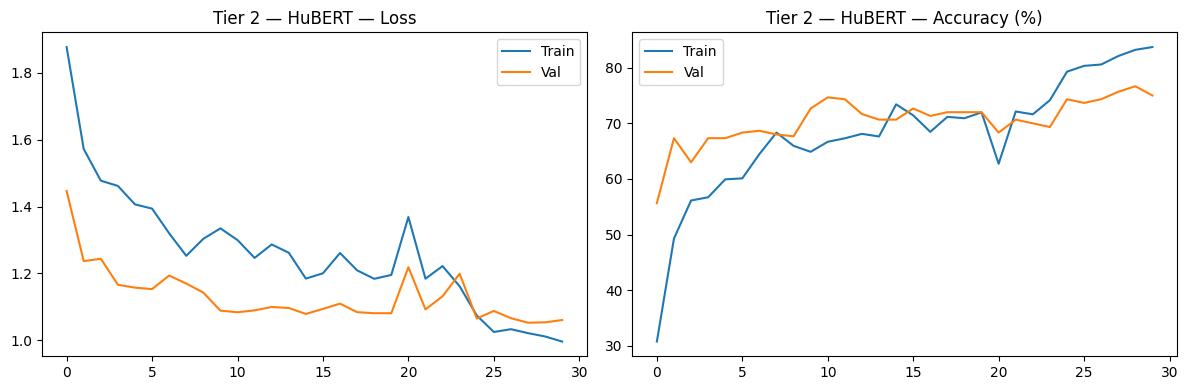

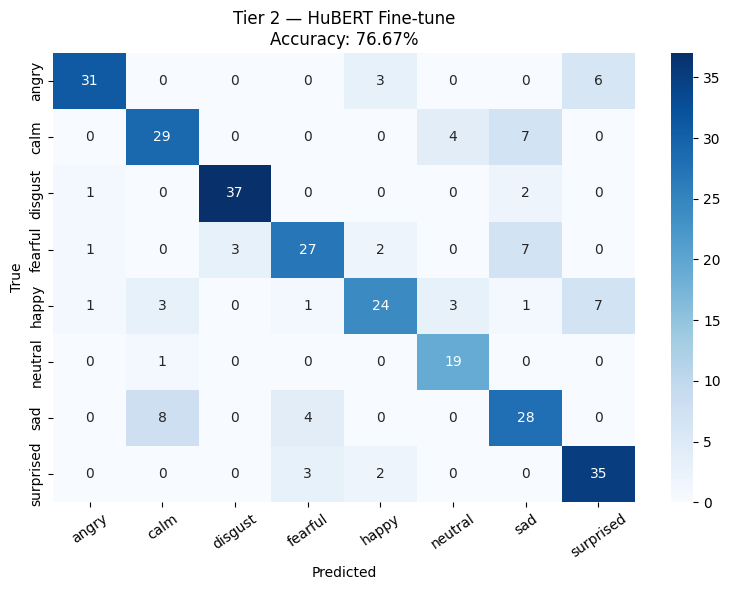

              precision    recall  f1-score   support

       angry       0.91      0.78      0.84        40
        calm       0.71      0.72      0.72        40
     disgust       0.93      0.93      0.93        40
     fearful       0.77      0.68      0.72        40
       happy       0.77      0.60      0.68        40
     neutral       0.73      0.95      0.83        20
         sad       0.62      0.70      0.66        40
   surprised       0.73      0.88      0.80        40

    accuracy                           0.77       300
   macro avg       0.77      0.78      0.77       300
weighted avg       0.77      0.77      0.77       300



In [9]:
# ═══════════════════════════════════════════
# Cell 9
# ═══════════════════════════════════════════
# ── Tier 2 Training: 3-phase progressive unfreezing ───────────

t2_criterion = LabelSmoothingCE(N_CLASSES, smoothing=0.1).to(device)
t2_history   = defaultdict(list)
t2_best_acc  = 0.0
t2_best_state = None
t2_scaler    = torch.cuda.amp.GradScaler()

def run_phase(model, train_dl, test_dl, optimizer, scheduler, criterion,
              scaler, n_epochs, phase_name, history):
    global t2_best_acc, t2_best_state
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\n  {phase_name} — {n_trainable/1e6:.2f}M trainable params')
    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, train_dl, optimizer, criterion,
            scheduler=scheduler, use_mixup=True, scaler=scaler
        )
        val_loss, val_acc, _, _ = evaluate(model, test_dl, criterion)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if val_acc > t2_best_acc:
            t2_best_acc = val_acc
            t2_best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'  Ep {epoch:2d}/{n_epochs} | Acc: {tr_acc*100:.1f}%/{val_acc*100:.1f}% | Best: {t2_best_acc*100:.2f}%')

print('='*60)
print('  TIER 2 TRAINING — HuBERT Fine-tuning')
print('='*60)

# Phase 1: Head only
t2_opt1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, t2_model.parameters()), lr=1e-3, weight_decay=1e-3
)
t2_sched1 = torch.optim.lr_scheduler.CosineAnnealingLR(t2_opt1, T_max=5*len(t2_train_dl))
run_phase(t2_model, t2_train_dl, t2_test_dl, t2_opt1, t2_sched1,
          t2_criterion, t2_scaler, 5, 'Phase 1 — Head only', t2_history)

# Phase 2: Unfreeze top 4 layers with layer-wise LR decay
t2_model.unfreeze_top_layers(n_layers=4)
param_groups = [
    {'params': t2_model.classifier.parameters(),   'lr': 1e-4},
    {'params': t2_model.attn_pool.parameters(),    'lr': 1e-4},
    {'params': t2_model.layer_weights,             'lr': 1e-4},
    {'params': [p for n, p in t2_model.hubert.named_parameters()
                if p.requires_grad and 'encoder.layers.1' in n], 'lr': 2e-5},
    {'params': [p for n, p in t2_model.hubert.named_parameters()
                if p.requires_grad and 'encoder.layers.1' not in n], 'lr': 5e-5},
]
t2_opt2   = torch.optim.AdamW(param_groups, weight_decay=1e-4)
t2_sched2 = torch.optim.lr_scheduler.CosineAnnealingLR(t2_opt2, T_max=15*len(t2_train_dl))
run_phase(t2_model, t2_train_dl, t2_test_dl, t2_opt2, t2_sched2,
          t2_criterion, t2_scaler, 15, 'Phase 2 — Top 4 layers + head', t2_history)

# Phase 3: Full fine-tune (optional, adds ~5 min)
t2_model.unfreeze_all()
t2_opt3   = torch.optim.AdamW(t2_model.parameters(), lr=5e-5, weight_decay=1e-4)
t2_sched3 = torch.optim.lr_scheduler.CosineAnnealingLR(t2_opt3, T_max=10*len(t2_train_dl))
run_phase(t2_model, t2_train_dl, t2_test_dl, t2_opt3, t2_sched3,
          t2_criterion, t2_scaler, 10, 'Phase 3 — Full fine-tune', t2_history)

# Final eval
t2_model.load_state_dict(t2_best_state)
_, t2_final_acc, t2_preds, t2_labels = evaluate(t2_model, t2_test_dl, t2_criterion)
ALL_RESULTS['Tier 2 — HuBERT Fine-tune'] = t2_final_acc
print(f'\nTier 2 FINAL accuracy: {t2_final_acc*100:.2f}%')
plot_history(t2_history, 'Tier 2 — HuBERT')
plot_confusion(t2_labels, t2_preds, CLASS_NAMES, 'Tier 2 — HuBERT Fine-tune', t2_final_acc)
print(classification_report(t2_labels, t2_preds, target_names=CLASS_NAMES))

In [10]:
# ═══════════════════════════════════════════
# Cell 10
# ═══════════════════════════════════════════
import whisper

# ── Whisper mel preprocessing (fixed 80-band mel) ─────────────
whisper_model_full = whisper.load_model('base')
whisper_encoder    = whisper_model_full.encoder.to(device)

# Freeze Whisper encoder (we only train the head + gating)
for p in whisper_encoder.parameters():
    p.requires_grad = False

def compute_acoustic_features(path):
    """Reuse your hand-crafted features as the acoustic branch."""
    y, sr = librosa.load(path, sr=16000, duration=4.0)
    if len(y) < 64000:
        y = np.pad(y, (0, 64000 - len(y)))
    feats = []
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    feats.extend(np.mean(mfcc, 1)); feats.extend(np.std(mfcc, 1))
    d = librosa.feature.delta(mfcc)
    feats.extend(np.mean(d, 1));  feats.extend(np.std(d, 1))
    d2 = librosa.feature.delta(mfcc, order=2)
    feats.extend(np.mean(d2, 1))
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    feats.extend(np.mean(chroma, 1)); feats.extend(np.std(chroma, 1))
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    feats.extend(np.mean(contrast, 1))
    try:
        f0, voiced, _ = librosa.pyin(y, fmin=50, fmax=400)
        f0v = f0[voiced]
        feats += [np.mean(f0v) if len(f0v) else 0,
                  np.std(f0v)  if len(f0v) else 0,
                  float(np.sum(voiced)) / len(voiced)]
    except:
        feats += [0.0, 0.0, 0.0]
    zcr = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)
    feats += [np.mean(zcr), np.std(zcr), np.mean(rms), np.std(rms)]
    centroid  = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    feats += [np.mean(centroid), np.mean(bandwidth)]
    return np.array(feats, dtype=np.float32)

print('Pre-computing acoustic features (Branch B)...')
print('This takes ~3 minutes on Colab T4.')

acoustic_cache = {}
all_paths = list(df['path'].unique())
for i, p in enumerate(all_paths):
    acoustic_cache[p] = compute_acoustic_features(p)
    if (i+1) % 100 == 0:
        print(f'  {i+1}/{len(all_paths)} done', end='\r')

ACOUSTIC_DIM = len(next(iter(acoustic_cache.values())))
print(f'\nAcoustic features: {ACOUSTIC_DIM} dims per sample')

# Normalize acoustic features
from sklearn.preprocessing import RobustScaler
ac_scaler = RobustScaler()
X_ac_train = np.stack([acoustic_cache[p] for p in df_train['path']])
X_ac_test  = np.stack([acoustic_cache[p] for p in df_test['path']])
X_ac_train = ac_scaler.fit_transform(X_ac_train)
X_ac_test  = ac_scaler.transform(X_ac_test)

# Store back as dict
for i, p in enumerate(df_train['path']): acoustic_cache[p + '_norm'] = X_ac_train[i]
for i, p in enumerate(df_test['path']):  acoustic_cache[p + '_norm'] = X_ac_test[i]

100%|███████████████████████████████████████| 139M/139M [00:02<00:00, 62.6MiB/s]


Pre-computing acoustic features (Branch B)...
This takes ~3 minutes on Colab T4.

Acoustic features: 240 dims per sample


In [11]:
# ═══════════════════════════════════════════
# Cell 11
# ═══════════════════════════════════════════
# ── Tier 3 Dataset ─────────────────────────────────────────────
class WhisperFusionDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df      = df
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Branch A: Whisper mel
        wav = load_wav(row['path'], target_sr=16000)
        if self.augment:
            gain = 10 ** (random.uniform(-4, 4) / 20)
            wav  = wav * gain
            if random.random() < 0.3:
                wav = wav + torch.randn_like(wav) * 0.002
        wav_np  = wav.numpy()
        mel_w   = whisper.log_mel_spectrogram(wav_np)  # (80, 3000)
        if mel_w.shape[1] < 3000:
            mel_w = torch.cat([mel_w,
                torch.full((80, 3000 - mel_w.shape[1]), -1.0, dtype=mel_w.dtype)], dim=1)
        else:
            mel_w = mel_w[:, :3000]

        # Branch B: acoustic features
        ac_feat = torch.tensor(acoustic_cache[row['path'] + '_norm'], dtype=torch.float32)

        return {'whisper_mel': mel_w, 'acoustic': ac_feat, 'label': int(row['label'])}

t3_train_ds = WhisperFusionDataset(df_train, augment=True)
t3_test_ds  = WhisperFusionDataset(df_test,  augment=False)
t3_train_dl = DataLoader(t3_train_ds, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
t3_test_dl  = DataLoader(t3_test_ds,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
print(f'Tier 3 dataset ready — train: {len(t3_train_ds)}, test: {len(t3_test_ds)}')

Tier 3 dataset ready — train: 1140, test: 300


In [12]:
# ═══════════════════════════════════════════
# Cell 12
# ═══════════════════════════════════════════
# ── Tier 3 Model: Whisper + Acoustic Fusion with Cross-modal Gating ──

class CrossModalGating(nn.Module):
    """
    Novel: Transformer embeddings gate the acoustic branch.
    Gate = sigmoid(W_t * transformer_emb + W_a * acoustic_emb + b)
    Output = gate * acoustic_emb  [residual connection]
    """
    def __init__(self, transformer_dim, acoustic_dim, out_dim):
        super().__init__()
        self.gate_net = nn.Sequential(
            nn.Linear(transformer_dim + acoustic_dim, out_dim),
            nn.Sigmoid()
        )
        self.acoustic_proj = nn.Linear(acoustic_dim, out_dim)

    def forward(self, t_emb, a_emb):
        gate = self.gate_net(torch.cat([t_emb, a_emb], dim=-1))  # (B, out_dim)
        a_proj = self.acoustic_proj(a_emb)                        # (B, out_dim)
        return gate * a_proj                                       # gated acoustic


class WhisperFusionSER(nn.Module):
    """
    Tier 3: Whisper encoder + acoustic features + cross-modal gating.
    """
    def __init__(self, n_classes=8, acoustic_dim=285, dropout=0.2):
        super().__init__()
        self.whisper_encoder = whisper_encoder  # already loaded, frozen
        whisper_dim = 512  # whisper-base encoder output dim

        # Attention pool over Whisper encoder output
        self.whisper_attn = nn.Sequential(
            nn.Linear(whisper_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        # Acoustic branch MLP
        self.acoustic_mlp = nn.Sequential(
            nn.Linear(acoustic_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(),
        )

        # Cross-modal gating
        self.gating = CrossModalGating(
            transformer_dim=whisper_dim,
            acoustic_dim=128,
            out_dim=128
        )

        # Fusion classifier
        fusion_dim = whisper_dim + 128
        self.classifier = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )

    def forward(self, whisper_mel, acoustic):
        # Branch A: Whisper encoder
        with torch.no_grad():
            t_hidden = self.whisper_encoder(whisper_mel)  # (B, T', 512)

        # Attention pooling
        scores  = self.whisper_attn(t_hidden).squeeze(-1)   # (B, T')
        weights = F.softmax(scores, dim=-1)
        t_emb   = (t_hidden * weights.unsqueeze(-1)).sum(1)  # (B, 512)

        # Branch B: Acoustic MLP
        a_emb = self.acoustic_mlp(acoustic)  # (B, 128)

        # Cross-modal gating
        a_gated = self.gating(t_emb, a_emb)  # (B, 128)

        # Fusion
        fused = torch.cat([t_emb, a_gated], dim=-1)  # (B, 640)
        return self.classifier(fused)

t3_model = WhisperFusionSER(n_classes=N_CLASSES, acoustic_dim=ACOUSTIC_DIM).to(device)
n_trainable = sum(p.numel() for p in t3_model.parameters() if p.requires_grad)
print(f'Tier 3 model — Trainable params: {n_trainable/1e6:.2f}M (head + gating only)')

Tier 3 model — Trainable params: 0.43M (head + gating only)


In [13]:
# ═══════════════════════════════════════════
# Cell 13
# ═══════════════════════════════════════════
# ── Custom train loop for Tier 3 (dual-input) ─────────────────
@torch.no_grad()
def evaluate_t3(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        mel  = batch['whisper_mel'].to(device)
        ac   = batch['acoustic'].to(device)
        y    = batch['label'].to(device)
        with torch.cuda.amp.autocast():
            logits = model(mel, ac)
        loss = criterion(logits, y)
        total_loss += loss.item() * mel.size(0)
        all_preds.extend(logits.argmax(-1).cpu().tolist())
        all_labels.extend(y.cpu().tolist())
    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(all_labels), acc, all_preds, all_labels


def train_t3_epoch(model, loader, optimizer, criterion, scheduler, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        mel = batch['whisper_mel'].to(device)
        ac  = batch['acoustic'].to(device)
        y   = batch['label'].to(device)
        optimizer.zero_grad()
        mel, y_a, y_b, lam = mixup_data(mel, y)
        with torch.cuda.amp.autocast():
            logits = model(mel, ac)
            loss   = mixup_criterion(criterion, logits, y_a, y_b, lam)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        if scheduler: scheduler.step()
        total_loss += loss.item() * mel.size(0)
        preds = logits.argmax(-1)
        correct += (lam * (preds == y_a).float() + (1-lam) * (preds == y_b).float()).sum().item()
        total += mel.size(0)
    return total_loss / total, correct / total

  TIER 3 TRAINING — Whisper + Acoustic Fusion
  Ep  5/40 | Acc: 58.3%/58.7% | Best: 58.67%
  Ep 10/40 | Acc: 63.3%/60.7% | Best: 60.67%
  Ep 15/40 | Acc: 63.7%/60.0% | Best: 60.67%
  Ep 20/40 | Acc: 74.9%/64.7% | Best: 64.67%
  Ep 25/40 | Acc: 76.3%/60.7% | Best: 64.67%
  Ep 30/40 | Acc: 74.8%/60.3% | Best: 64.67%
  Ep 35/40 | Acc: 77.8%/59.3% | Best: 64.67%
  Ep 40/40 | Acc: 75.5%/62.3% | Best: 64.67%

Tier 3 FINAL accuracy: 64.67%


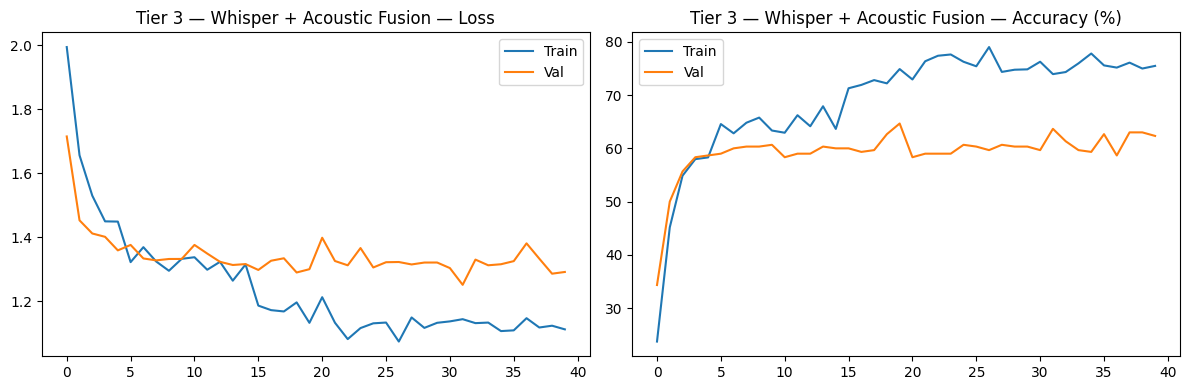

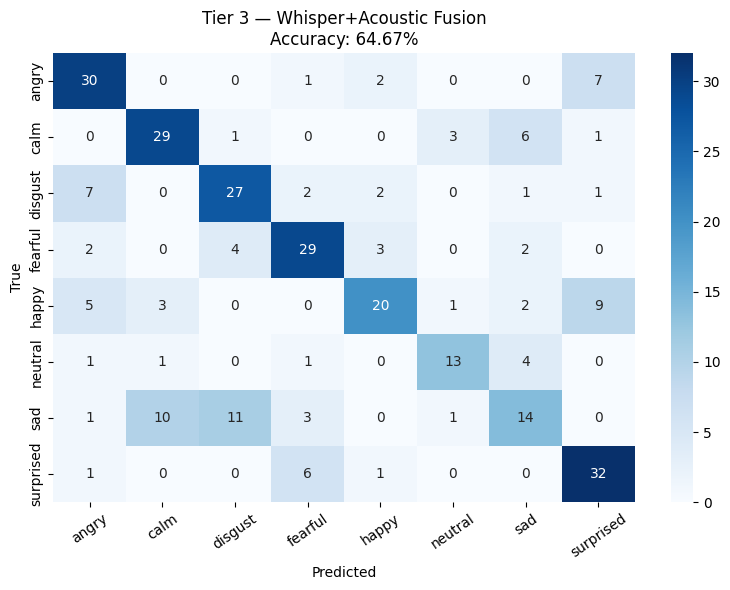

              precision    recall  f1-score   support

       angry       0.64      0.75      0.69        40
        calm       0.67      0.72      0.70        40
     disgust       0.63      0.68      0.65        40
     fearful       0.69      0.72      0.71        40
       happy       0.71      0.50      0.59        40
     neutral       0.72      0.65      0.68        20
         sad       0.48      0.35      0.41        40
   surprised       0.64      0.80      0.71        40

    accuracy                           0.65       300
   macro avg       0.65      0.65      0.64       300
weighted avg       0.64      0.65      0.64       300



In [14]:
# ═══════════════════════════════════════════
# Cell 14
# ═══════════════════════════════════════════
T3_EPOCHS    = 40
t3_criterion = LabelSmoothingCE(N_CLASSES, 0.1).to(device)
t3_optimizer = torch.optim.AdamW(t3_model.parameters(), lr=5e-4, weight_decay=1e-4)
t3_scaler    = torch.cuda.amp.GradScaler()
t3_sched     = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    t3_optimizer, T_0=10 * len(t3_train_dl), T_mult=2
)

t3_history   = defaultdict(list)
t3_best_acc  = 0.0
t3_best_state = None

print('='*60)
print('  TIER 3 TRAINING — Whisper + Acoustic Fusion')
print('='*60)
for epoch in range(1, T3_EPOCHS + 1):
    tr_loss, tr_acc = train_t3_epoch(
        t3_model, t3_train_dl, t3_optimizer, t3_criterion, t3_sched, t3_scaler
    )
    val_loss, val_acc, _, _ = evaluate_t3(t3_model, t3_test_dl, t3_criterion)
    t3_history['train_loss'].append(tr_loss)
    t3_history['train_acc'].append(tr_acc)
    t3_history['val_loss'].append(val_loss)
    t3_history['val_acc'].append(val_acc)
    if val_acc > t3_best_acc:
        t3_best_acc = val_acc
        t3_best_state = {k: v.cpu().clone() for k, v in t3_model.state_dict().items()}
    if epoch % 5 == 0:
        print(f'  Ep {epoch:2d}/{T3_EPOCHS} | Acc: {tr_acc*100:.1f}%/{val_acc*100:.1f}% | Best: {t3_best_acc*100:.2f}%')

t3_model.load_state_dict(t3_best_state)
_, t3_final_acc, t3_preds, t3_labels = evaluate_t3(t3_model, t3_test_dl, t3_criterion)
ALL_RESULTS['Tier 3 — Whisper+Acoustic Fusion'] = t3_final_acc
print(f'\nTier 3 FINAL accuracy: {t3_final_acc*100:.2f}%')
plot_history(t3_history, 'Tier 3 — Whisper + Acoustic Fusion')
plot_confusion(t3_labels, t3_preds, CLASS_NAMES, 'Tier 3 — Whisper+Acoustic Fusion', t3_final_acc)
print(classification_report(t3_labels, t3_preds, target_names=CLASS_NAMES))

  FINAL RESULTS SUMMARY
  Old baseline (MFCC+MLP)                56.60%  ██████████████████████
  Tier 1 — CNN+Transformer               60.00%  ████████████████████████
  Tier 3 — Whisper+Acoustic Fusion       64.67%  █████████████████████████
  Previous best (Stacked Ens.)           75.00%  ██████████████████████████████
  Tier 2 — HuBERT Fine-tune              76.67%  ██████████████████████████████  ← BEST

  Best model     : Tier 2 — HuBERT Fine-tune
  Best accuracy  : 76.67%
  Δ over baseline: +20.07 pp
  Δ over prev best: +1.67 pp


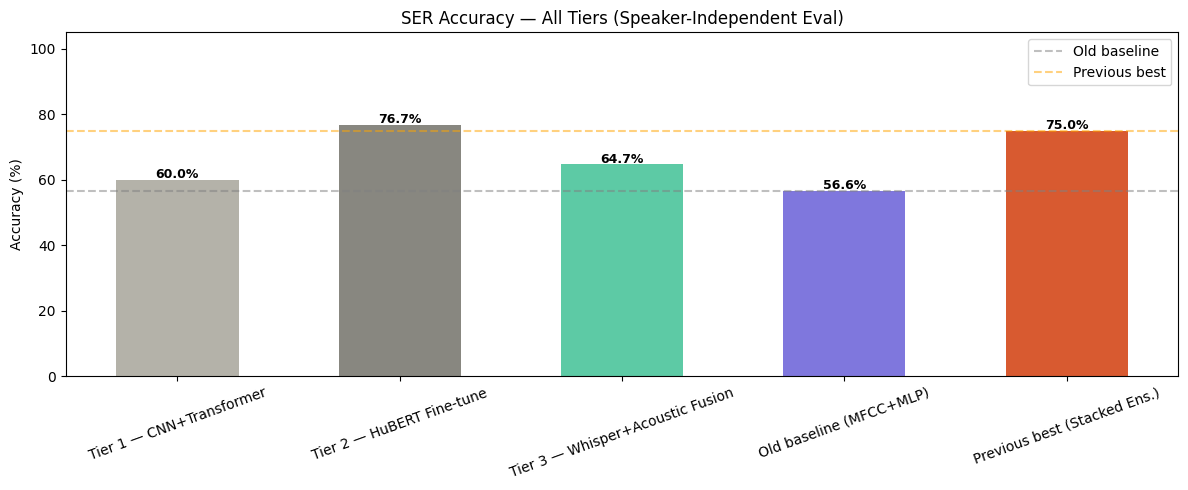

Saved: tier_comparison.png


In [15]:
# ═══════════════════════════════════════════
# Cell 15
# ═══════════════════════════════════════════
# ── Final comparison across all tiers ─────────────────────────
baseline_acc = 0.566
prev_best    = 0.750

ALL_RESULTS['Old baseline (MFCC+MLP)']     = baseline_acc
ALL_RESULTS['Previous best (Stacked Ens.)'] = prev_best

print('='*60)
print('  FINAL RESULTS SUMMARY')
print('='*60)
for name, acc in sorted(ALL_RESULTS.items(), key=lambda x: x[1]):
    bar  = '█' * int(acc * 40)
    flag = '  ← BEST' if acc == max(ALL_RESULTS.values()) else ''
    print(f'  {name:<38} {acc*100:5.2f}%  {bar}{flag}')

best_name = max(ALL_RESULTS, key=ALL_RESULTS.get)
best_acc  = ALL_RESULTS[best_name]
print(f'\n  Best model     : {best_name}')
print(f'  Best accuracy  : {best_acc*100:.2f}%')
print(f'  Δ over baseline: +{(best_acc - baseline_acc)*100:.2f} pp')
print(f'  Δ over prev best: +{(best_acc - prev_best)*100:.2f} pp')

# Plot
names  = list(ALL_RESULTS.keys())
accs   = [v*100 for v in ALL_RESULTS.values()]
colors = ['#B4B2A9','#888780','#5DCAA5','#7F77DD','#D85A30']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, accs, color=colors, width=0.55)
ax.axhline(y=baseline_acc*100, color='gray',   ls='--', alpha=0.5, label='Old baseline')
ax.axhline(y=prev_best*100,    color='orange', ls='--', alpha=0.5, label='Previous best')
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)')
ax.set_title('SER Accuracy — All Tiers (Speaker-Independent Eval)')
ax.legend(); ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('tier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tier_comparison.png')